<a href="https://colab.research.google.com/github/SATYA012904/Disease-Symptom-Pattern-Discovery/blob/main/Untitled27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
from sklearn.utils import shuffle

In [107]:
df = pd.read_csv("Final_Augmented_dataset_Diseases_and_Symptoms.csv")

In [108]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,hoarse voice,sore throat,difficulty speaking,cough,nasal congestion,throat swelling,diminished hearing,lump in throat,throat feels tight,difficulty in swallowing,skin swelling,retention of urine,groin mass,leg pain,hip pain,suprapubic pain,blood in stool,lack of growth,emotional symptoms,elbow weakness,back weakness,pus in sputum,symptoms of the scrotum and testes,swelling of scrotum,pain in testicles,flatulence,pus draining from ear,jaundice,mass in scrotum,white discharge from eye,irritable infant,abusing alcohol,fainting,hostile behavior,drug abuse,sharp abdominal pain,feeling ill,vomiting,headache,nausea,diarrhea,vaginal itching,vaginal dryness,painful urination,involuntary urination,pain during intercourse,frequent urination,lower abdominal pain,vaginal discharge,blood in urine,hot flashes,intermenstrual bleeding,hand or finger pain,wrist pain,hand or finger swelling,arm pain,wrist swelling,arm stiffness or tightness,arm swelling,hand or finger stiffness or tightness,wrist stiffness or tightness,lip swelling,toothache,abnormal appearing skin,skin lesion,acne or pimples,dry lips,facial pain,mouth ulcer,skin growth,eye deviation,diminished vision,double vision,cross-eyed,symptoms of eye,pain in eye,eye moves abnormally,abnormal movement of eyelid,foreign body sensation in eye,irregular appearing scalp,swollen lymph nodes,back pain,neck pain,low back pain,pain of the anus,pain during pregnancy,pelvic pain,impotence,infant spitting up,vomiting blood,regurgitation,burning abdominal pain,restlessness,symptoms of infants,wheezing,peripheral edema,neck mass,ear pain,jaw swelling,mouth dryness,neck swelling,knee pain,foot or toe pain,bowlegged or knock-kneed,ankle pain,bones are painful,knee weakness,elbow pain,knee swelling,skin moles,knee lump or mass,weight gain,problems with movement,knee stiffness or tightness,leg swelling,foot or toe swelling,heartburn,smoking problems,muscle pain,infant feeding problem,recent weight loss,problems with shape or size of breast,underweight,difficulty eating,scanty menstrual flow,vaginal pain,vaginal redness,vulvar irritation,weakness,decreased heart rate,increased heart rate,bleeding or discharge from nipple,ringing in ear,plugged feeling in ear,itchy ear(s),frontal headache,fluid in ear,neck stiffness or tightness,spots or clouds in vision,eye redness,lacrimation,itchiness of eye,blindness,eye burns or stings,itchy eyelid,feeling cold,decreased appetite,excessive appetite,excessive anger,loss of sensation,focal weakness,slurring words,symptoms of the face,disturbance of memory,paresthesia,side pain,fever,shoulder pain,shoulder stiffness or tightness,shoulder weakness,arm cramps or spasms,shoulder swelling,tongue lesions,leg cramps or spasms,abnormal appearing tongue,ache all over,lower body pain,problems during pregnancy,spotting or bleeding during pregnancy,cramps and spasms,upper abdominal pain,stomach bloating,changes in stool appearance,unusual color or odor to urine,kidney mass,swollen abdomen,symptoms of prostate,leg stiffness or tightness,difficulty breathing,rib pain,joint pain,muscle stiffness or tightness,pallor,hand or finger lump or mass,chills,groin pain,fatigue,abdominal distention,regurgitation.1,symptoms of the kidneys,melena,flushing,coughing up sputum,seizures,delusions or hallucinations,shoulder cramps or spasms,joint stiffness or tightness,pain or soreness of breast,excessive urination at night,bleeding from eye,rectal bleeding,constipation,temper problems,coryza,wrist weakness,eye strain,hemoptysis,lymphedema,skin on leg or foot looks infected,allergic reaction,congestion in chest,muscle swelling,pus in urine,abnormal size or shape of ear,low back weakness,sleepiness,apnea,abnormal breathing sounds,excessive growth,elbow cramps or spasms,feeling h

In [109]:
df.shape

(246945, 378)

In [110]:
df.columns

Index(['diseases', 'anxiety and nervousness', 'depression',
       'shortness of breath', 'depressive or psychotic symptoms',
       'sharp chest pain', 'dizziness', 'insomnia',
       'abnormal involuntary movements', 'chest tightness',
       ...
       'stuttering or stammering', 'problems with orgasm', 'nose deformity',
       'lump over jaw', 'sore in nose', 'hip weakness', 'back swelling',
       'ankle stiffness or tightness', 'ankle weakness', 'neck weakness'],
      dtype='object', length=378)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


In [112]:
pd.set_option('display.max_columns', None) # Set to None to display all columns
pd.set_option('display.max_rows', None)    # Set to None to display all rows (if needed)
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,hoarse voice,sore throat,difficulty speaking,cough,nasal congestion,throat swelling,diminished hearing,lump in throat,throat feels tight,difficulty in swallowing,skin swelling,retention of urine,groin mass,leg pain,hip pain,suprapubic pain,blood in stool,lack of growth,emotional symptoms,elbow weakness,back weakness,pus in sputum,symptoms of the scrotum and testes,swelling of scrotum,pain in testicles,flatulence,pus draining from ear,jaundice,mass in scrotum,white discharge from eye,irritable infant,abusing alcohol,fainting,hostile behavior,drug abuse,sharp abdominal pain,feeling ill,vomiting,headache,nausea,diarrhea,vaginal itching,vaginal dryness,painful urination,involuntary urination,pain during intercourse,frequent urination,lower abdominal pain,vaginal discharge,blood in urine,hot flashes,intermenstrual bleeding,hand or finger pain,wrist pain,hand or finger swelling,arm pain,wrist swelling,arm stiffness or tightness,arm swelling,hand or finger stiffness or tightness,wrist stiffness or tightness,lip swelling,toothache,abnormal appearing skin,skin lesion,acne or pimples,dry lips,facial pain,mouth ulcer,skin growth,eye deviation,diminished vision,double vision,cross-eyed,symptoms of eye,pain in eye,eye moves abnormally,abnormal movement of eyelid,foreign body sensation in eye,irregular appearing scalp,swollen lymph nodes,back pain,neck pain,low back pain,pain of the anus,pain during pregnancy,pelvic pain,impotence,infant spitting up,vomiting blood,regurgitation,burning abdominal pain,restlessness,symptoms of infants,wheezing,peripheral edema,neck mass,ear pain,jaw swelling,mouth dryness,neck swelling,knee pain,foot or toe pain,bowlegged or knock-kneed,ankle pain,bones are painful,knee weakness,elbow pain,knee swelling,skin moles,knee lump or mass,weight gain,problems with movement,knee stiffness or tightness,leg swelling,foot or toe swelling,heartburn,smoking problems,muscle pain,infant feeding problem,recent weight loss,problems with shape or size of breast,underweight,difficulty eating,scanty menstrual flow,vaginal pain,vaginal redness,vulvar irritation,weakness,decreased heart rate,increased heart rate,bleeding or discharge from nipple,ringing in ear,plugged feeling in ear,itchy ear(s),frontal headache,fluid in ear,neck stiffness or tightness,spots or clouds in vision,eye redness,lacrimation,itchiness of eye,blindness,eye burns or stings,itchy eyelid,feeling cold,decreased appetite,excessive appetite,excessive anger,loss of sensation,focal weakness,slurring words,symptoms of the face,disturbance of memory,paresthesia,side pain,fever,shoulder pain,shoulder stiffness or tightness,shoulder weakness,arm cramps or spasms,shoulder swelling,tongue lesions,leg cramps or spasms,abnormal appearing tongue,ache all over,lower body pain,problems during pregnancy,spotting or bleeding during pregnancy,cramps and spasms,upper abdominal pain,stomach bloating,changes in stool appearance,unusual color or odor to urine,kidney mass,swollen abdomen,symptoms of prostate,leg stiffness or tightness,difficulty breathing,rib pain,joint pain,muscle stiffness or tightness,pallor,hand or finger lump or mass,chills,groin pain,fatigue,abdominal distention,regurgitation.1,symptoms of the kidneys,melena,flushing,coughing up sputum,seizures,delusions or hallucinations,shoulder cramps or spasms,joint stiffness or tightness,pain or soreness of breast,excessive urination at night,bleeding from eye,rectal bleeding,constipation,temper problems,coryza,wrist weakness,eye strain,hemoptysis,lymphedema,skin on leg or foot looks infected,allergic reaction,congestion in chest,muscle swelling,pus in urine,abnormal size or shape of ear,low back weakness,sleepiness,apnea,abnormal breathing sounds,excessive growth,elbow cramps or spasms,feeling h

In [113]:
data = pd.read_csv("Final_Augmented_dataset_Diseases_and_Symptoms.csv")

In [114]:
data.isnull().sum().sum()

np.int64(0)

In [115]:
df.isnull().sum()

,0
diseases,0
anxiety and nervousness,0
depression,0
shortness of breath,0
depressive or psychotic symptoms,0
sharp chest pain,0
dizziness,0
insomnia,0
abnormal involuntary movements,0
chest tightness,0


In [116]:
df.duplicated().sum()

np.int64(57298)

In [117]:
df['diseases'].value_counts()

,count
diseases,
cystitis,1219
nose disorder,1218
vulvodynia,1218
complex regional pain syndrome,1217
spondylosis,1216
vaginal cyst,1215
esophagitis,1215
peripheral nerve disorder,1215
hypoglycemia,1215


In [118]:
df.describe()

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,irregular heartbeat,breathing fast,hoarse voice,sore throat,difficulty speaking,cough,nasal congestion,throat swelling,diminished hearing,lump in throat,throat feels tight,difficulty in swallowing,skin swelling,retention of urine,groin mass,leg pain,hip pain,suprapubic pain,blood in stool,lack of growth,emotional symptoms,elbow weakness,back weakness,pus in sputum,symptoms of the scrotum and testes,swelling of scrotum,pain in testicles,flatulence,pus draining from ear,jaundice,mass in scrotum,white discharge from eye,irritable infant,abusing alcohol,fainting,hostile behavior,drug abuse,sharp abdominal pain,feeling ill,vomiting,headache,nausea,diarrhea,vaginal itching,vaginal dryness,painful urination,involuntary urination,pain during intercourse,frequent urination,lower abdominal pain,vaginal discharge,blood in urine,hot flashes,intermenstrual bleeding,hand or finger pain,wrist pain,hand or finger swelling,arm pain,wrist swelling,arm stiffness or tightness,arm swelling,hand or finger stiffness or tightness,wrist stiffness or tightness,lip swelling,toothache,abnormal appearing skin,skin lesion,acne or pimples,dry lips,facial pain,mouth ulcer,skin growth,eye deviation,diminished vision,double vision,cross-eyed,symptoms of eye,pain in eye,eye moves abnormally,abnormal movement of eyelid,foreign body sensation in eye,irregular appearing scalp,swollen lymph nodes,back pain,neck pain,low back pain,pain of the anus,pain during pregnancy,pelvic pain,impotence,infant spitting up,vomiting blood,regurgitation,burning abdominal pain,restlessness,symptoms of infants,wheezing,peripheral edema,neck mass,ear pain,jaw swelling,mouth dryness,neck swelling,knee pain,foot or toe pain,bowlegged or knock-kneed,ankle pain,bones are painful,knee weakness,elbow pain,knee swelling,skin moles,knee lump or mass,weight gain,problems with movement,knee stiffness or tightness,leg swelling,foot or toe swelling,heartburn,smoking problems,muscle pain,infant feeding problem,recent weight loss,problems with shape or size of breast,underweight,difficulty eating,scanty menstrual flow,vaginal pain,vaginal redness,vulvar irritation,weakness,decreased heart rate,increased heart rate,bleeding or discharge from nipple,ringing in ear,plugged feeling in ear,itchy ear(s),frontal headache,fluid in ear,neck stiffness or tightness,spots or clouds in vision,eye redness,lacrimation,itchiness of eye,blindness,eye burns or stings,itchy eyelid,feeling cold,decreased appetite,excessive appetite,excessive anger,loss of sensation,focal weakness,slurring words,symptoms of the face,disturbance of memory,paresthesia,side pain,fever,shoulder pain,shoulder stiffness or tightness,shoulder weakness,arm cramps or spasms,shoulder swelling,tongue lesions,leg cramps or spasms,abnormal appearing tongue,ache all over,lower body pain,problems during pregnancy,spotting or bleeding during pregnancy,cramps and spasms,upper abdominal pain,stomach bloating,changes in stool appearance,unusual color or odor to urine,kidney mass,swollen abdomen,symptoms of prostate,leg stiffness or tightness,difficulty breathing,rib pain,joint pain,muscle stiffness or tightness,pallor,hand or finger lump or mass,chills,groin pain,fatigue,abdominal distention,regurgitation.1,symptoms of the kidneys,melena,flushing,coughing up sputum,seizures,delusions or hallucinations,shoulder cramps or spasms,joint stiffness or tightness,pain or soreness of breast,excessive urination at night,bleeding from eye,rectal bleeding,constipation,temper problems,coryza,wrist weakness,eye strain,hemoptysis,lymphedema,skin on leg or foot looks infected,allergic reaction,congestion in chest,muscle swelling,pus in urine,abnormal size or shape of ear,low back weakness,sleepiness,apnea,abnormal breathing sounds,excessive growth,elbow cramps or spasms,feeling hot and co

In [119]:
df['diseases'].nunique()

773

In [120]:
len(df.columns) - 1

377



# DATA CLEANING & PREPROCESSING



In [121]:
df.duplicated().sum()

np.int64(57298)

In [122]:
zero_columns = []

for col in df.columns:

    if df[col].sum() == 0:
        zero_columns.append(col)




print("\nColumns Having All Zeros:")
print(zero_columns)
print("\nTotal Zero Columns:")
print(len(zero_columns))


Columns Having All Zeros:
['pus in sputum', 'underweight', 'arm cramps or spasms', 'abnormal appearing tongue', 'pallor', 'shoulder cramps or spasms', 'joint stiffness or tightness', 'eye strain', 'pus in urine', 'abnormal size or shape of ear', 'elbow cramps or spasms', 'feeling hot and cold', 'nailbiting', 'hip swelling', 'foot or toe cramps or spasms', 'low back swelling', 'hip lump or mass', 'feet turned in', 'elbow stiffness or tightness', 'mass on ear', 'throat irritation', 'swollen tongue', 'disturbance of smell or taste', 'discharge in stools', 'pupils unequal', 'sleepwalking', 'skin oiliness', 'knee cramps or spasms', 'posture problems', 'bleeding in mouth', 'tongue bleeding', 'change in skin mole size or color', 'polyuria', 'infrequent menstruation', 'mass on vulva', 'jaw pain', 'eyelid retracted', 'elbow lump or mass', 'tongue pain', 'low back stiffness or tightness', 'skin on head or neck looks infected', 'stuttering or stammering', 'problems with orgasm', 'nose deformity'

In [123]:
df = df.drop(columns=zero_columns)


In [124]:
df.shape

(246945, 329)

In [125]:
df.dtypes

,0
diseases,object
anxiety and nervousness,int64
depression,int64
shortness of breath,int64
depressive or psychotic symptoms,int64
sharp chest pain,int64
dizziness,int64
insomnia,int64
abnormal involuntary movements,int64
chest tightness,int64


In [126]:
# # ==========================================
# # FIND SPARSE COLUMNS
# # ==========================================


# # Store sparse columns
# sparse_columns = []

# # Threshold
# threshold = 1

# for col in df.drop('diseases', axis=1).columns:

#     if df[col].sum() < threshold:
#         sparse_columns.append(col)

# # Print columns
# print("Columns Having Less Than", threshold, "Ones:\n")

# for col in sparse_columns:
#     print(col)

# # Total sparse columns
# print("\nTotal Sparse Columns:")
# print(len(sparse_columns))

In [127]:
# df = df.drop(columns=sparse_columns)

In [128]:
# df.shape

# EXPLORATORY DATA ANALYSIS (EDA)

In [129]:
symptom_counts = df.drop(columns=['diseases']).sum().sort_values(ascending=False)

In [130]:
symptom_counts.head(20)

,0
sharp abdominal pain,32307
vomiting,27874
headache,24719
cough,24296
sharp chest pain,24016
nausea,23687
back pain,21809
shortness of breath,21346
fever,20394
dizziness,17272


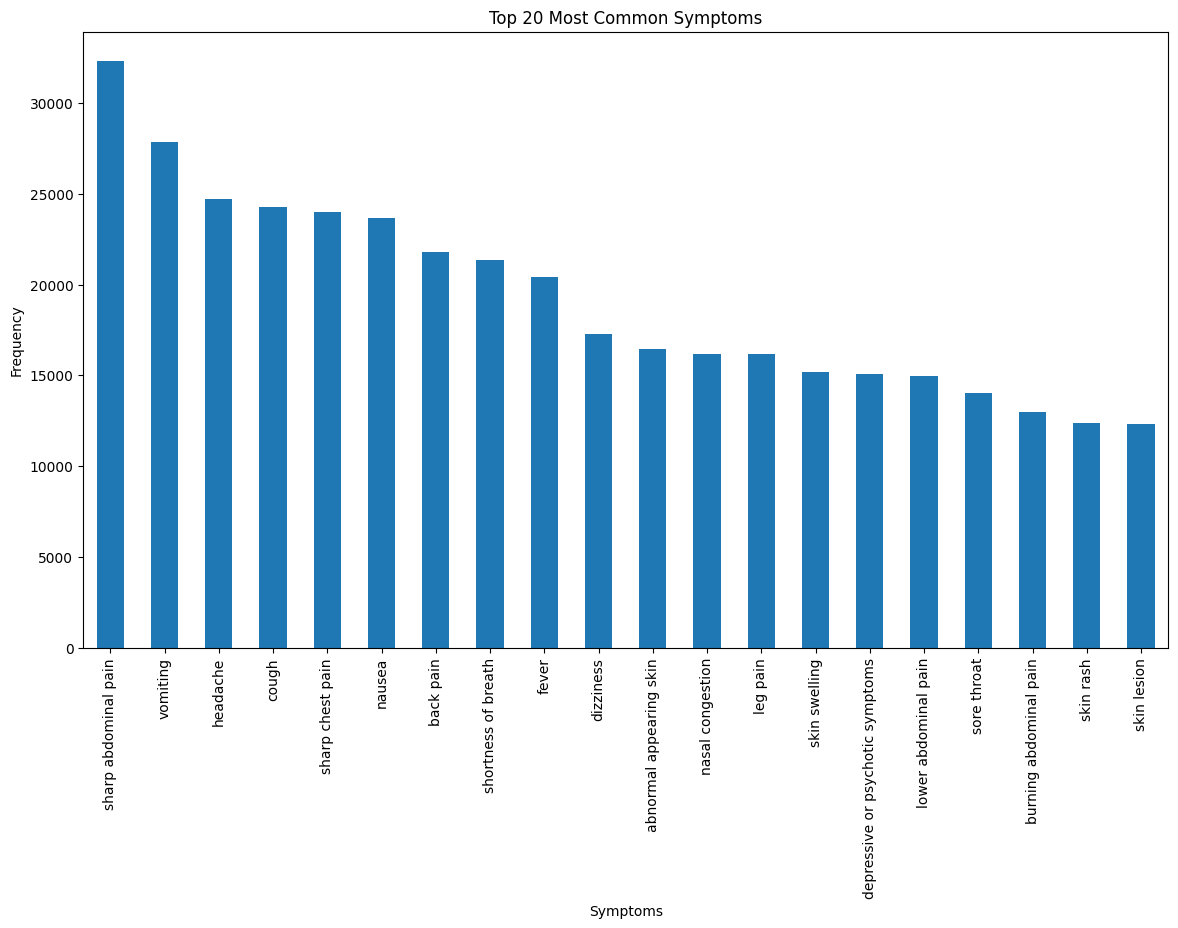

In [131]:
plt.figure(figsize=(14,8))
symptom_counts.head(20).plot(kind='bar')
plt.title("Top 20 Most Common Symptoms")
plt.xlabel("Symptoms")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

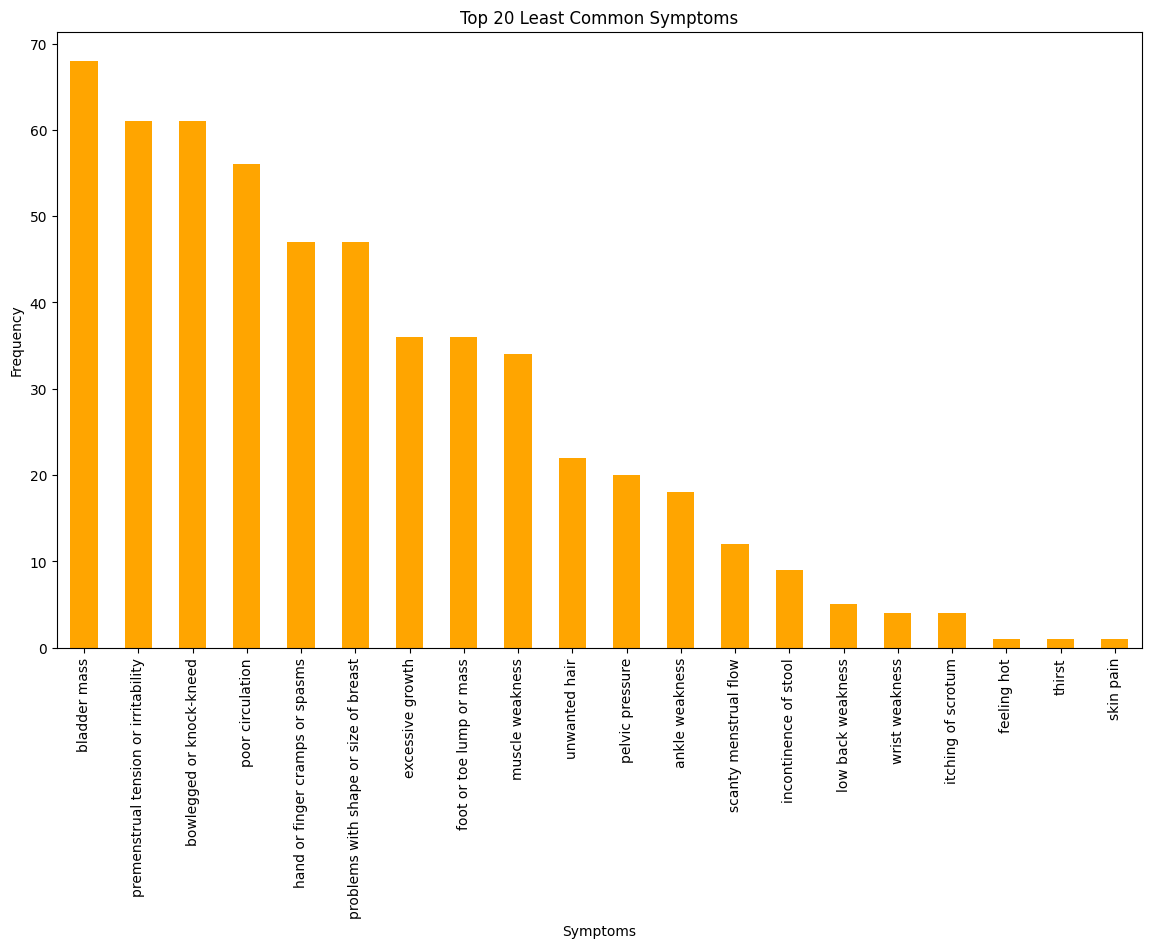

In [132]:
plt.figure(figsize=(14,8))
symptom_counts.tail(20).plot(kind='bar', color='orange')
plt.title("Top 20 Least Common Symptoms")
plt.xlabel("Symptoms")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

In [ ]:
correlation_matrix = df.drop(columns=['diseases']).corr()
plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm"
)

plt.title("Symptom Correlation Heatmap")

plt.show()

In [ ]:
corr_pairs = correlation_matrix.stack()

corr_pairs = corr_pairs.sort_values(ascending=False)

# Remove self correlation
corr_pairs = corr_pairs[corr_pairs < 1]

print("\nTop Correlated Symptoms:\n")

print(corr_pairs.head(20))

In [ ]:
df = df.drop(columns=['regurgitation.1'])

In [ ]:
symptoms_per_patient = df.drop(columns=['diseases']).sum(axis=1)

plt.figure(figsize=(10,6))
sns.histplot(symptoms_per_patient, bins=30)
plt.title("Number of Symptoms Per Patient")
plt.xlabel("Number of Symptoms")
plt.ylabel("Number of Patients")
plt.show()

# PCA DIMENSIONALITY REDUCTION

In [ ]:
X = df.drop(columns=['diseases'])
y = df['diseases']

In [ ]:
X.shape

In [ ]:
print(X.isnull().sum().sum())

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

import joblib
joblib.dump(scaler, "scaler.pkl")

In [ ]:

pca = PCA()
pca_data = pca.fit_transform(scaled_data)

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(
    cumulative_variance,
    marker='o'
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [ ]:
n_components = np.argmax(cumulative_variance >= 0.80) + 1

In [ ]:
n_components

In [ ]:
pca_final = PCA(n_components=n_components)
pca_final_data = pca_final.fit_transform(scaled_data)
print("\nFinal PCA Shape:")
print(pca_final_data.shape)

import joblib
joblib.dump(pca_final, "pca_model.pkl")

In [ ]:
pca_df = pd.DataFrame(pca_final_data)
X_pca = pca_final_data

In [ ]:
inertia = []
K = range(2, 15)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [ ]:
# silhouette_scores = []

# for k in K:

#     kmeans = KMeans(
#         n_clusters=k,
#         random_state=42,
#         n_init=10
#     )

#     cluster_labels = kmeans.fit_predict(X_pca)
#     score = silhouette_score(X_pca, cluster_labels)
#     silhouette_scores.append(score)

In [ ]:
# plt.figure(figsize=(10,6))

# plt.plot(K, silhouette_scores, marker='o')

# plt.xlabel("Number of Clusters")

# plt.ylabel("Silhouette Score")

# plt.title("Silhouette Scores")

# plt.grid()

# plt.show()

In [ ]:
# print("\nSilhouette Scores:\n")

# for k, score in zip(K, silhouette_scores):
#     print(f"K = {k} --> Score = {score:.4f}")

#  CLUSTERING

In [ ]:
kmeans = KMeans(
    n_clusters=13,
    random_state=42,
    n_init=10
)

In [ ]:
clusters = kmeans.fit_predict(X_pca)
print("K-Means Clustering Completed")

import joblib
joblib.dump(kmeans, "kmeans_model.pkl")

In [ ]:
df['Cluster'] = clusters

In [ ]:
print("\nCluster Distribution:\n")
print(df['Cluster'].value_counts())

In [ ]:
feature_columns = df.drop(
    columns=['diseases', 'Cluster']
).columns

In [ ]:
for cluster_num in sorted(df['Cluster'].unique()):

    print("\n")
    print("="*50)
    print(f"CLUSTER {cluster_num}")
    print("="*50)

    cluster_num = df[
        df['Cluster'] == cluster_num
    ]

    # Mean symptom frequency
    symptom_means = cluster_num[
        feature_columns
    ].mean()

    # Top 10 symptoms
    top_symptoms = symptom_means.sort_values(
        ascending=False
    ).head(10)

    print("\nTop Symptoms:\n")

    print(top_symptoms)

In [ ]:
pca_2d = PCA(n_components=2)

X_2d = pca_2d.fit_transform(X_pca)

print("2D PCA Shape:")
print(X_2d.shape)

In [ ]:
scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=clusters,
    cmap='tab20',
    s=10,
    alpha=0.7
)

# Labels
plt.title("Disease Symptom Pattern Clusters", fontsize=16)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

# ------------------------------------------
# CREATE LEGEND
# ------------------------------------------

legend = plt.legend(
    *scatter.legend_elements(),
    title="Clusters",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.gca().add_artist(legend)

# Show plot
plt.show()

In [ ]:
cluster_names = {
    0: "Arm & Shoulder Disorders",
    1: "Dental & Oral Disorders",
    2: "Respiratory & Infection Disorders",
    3: "Urinary & Prostate Disorders",
    4: "Leg & Joint Disorders",
    5: "Skin Mass & Tumor Disorders",
    6: "Gynecological & Pregnancy Disorders",
    7: "Vision & Retinal Disorders",
    8: "Eye Infection & Inflammation Disorders",
    9: "Spine & Nerve Pain Disorders",
    10: "Gastrointestinal Disorders",
    11: "Psychiatric & Behavioral Disorders",
    12: "Skin & Dermatological Disorders"
}

In [ ]:
cmap = plt.get_cmap('tab20')

# Create figure
plt.figure(figsize=(16,12))

# Scatter plot
scatter = plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=clusters,
    cmap=cmap,
    s=10,
    alpha=0.7
)

# ------------------------------------------
# CREATE CUSTOM LEGEND WITH COLORS
# ------------------------------------------

handles = []

for cluster_id in np.unique(clusters):

    color = cmap(cluster_id)

    handles.append(
        plt.Line2D(
            [],
            [],
            marker='o',
            linestyle='',
            markersize=10,
            color=color,
            label=f"{cluster_id} : {cluster_names[cluster_id]}"
        )
    )

# Add legend
plt.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Disease Clusters"
)

# Titles
plt.title(
    "Disease Symptom Pattern Clusters",
    fontsize=18
)

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.show()

# TOP DISEASES PER CLUSTER

In [ ]:
for cluster_num in sorted(df['Cluster'].unique()):

    print("\n")
    print("="*50)
    print(f"CLUSTER {cluster_num}")
    print("="*50)

    # Select cluster data
    cluster_num = df[
        df['Cluster'] == cluster_num
    ]

    # Top diseases
    top_diseases = cluster_num[
        'diseases'
    ].value_counts().head(10)

    print("\nTop Diseases:\n")

    print(top_diseases)

# DBSCAN


In [ ]:
# dbscan = DBSCAN(
#     eps=3,
#     min_samples=10
# )

# dbscan_clusters = dbscan.fit_predict(X_pca)

In [ ]:
# df['DBSCAN_Cluster'] = dbscan_clusters

In [ ]:
# print("\nDBSCAN Cluster Distribution:\n")

# print(df['DBSCAN_Cluster'].value_counts())

In [ ]:
# outliers = np.sum(dbscan_clusters == -1)

# print("\nTotal Outliers:")
# print(outliers)

In [ ]:
# plt.figure(figsize=(14,10))

# scatter = plt.scatter(
#     X_2d[:,0],
#     X_2d[:,1],
#     c=dbscan_clusters,
#     cmap='tab20',
#     s=10,
#     alpha=0.7
# )

# plt.title("DBSCAN Clustering & Outlier Detection")

# plt.xlabel("PCA Component 1")

# plt.ylabel("PCA Component 2")

# plt.colorbar(scatter)

# plt.show()

In [ ]:
# # ==========================================
# # GMM ON FULL DATASET
# # ==========================================

# from sklearn.mixture import GaussianMixture
# from sklearn.metrics import silhouette_score

# gmm_scores = []

# K_range = range(2, 15)

# for k in K_range:

#     print(f"\nRunning GMM for K = {k}")

#     # Create GMM model
#     gmm = GaussianMixture(
#         n_components=k,
#         covariance_type='full',
#         random_state=42
#     )

#     # Fit and predict
#     gmm_labels = gmm.fit_predict(
#         pca_final_data
#     )

#     # FULL DATASET SILHOUETTE SCORE
#     score = silhouette_score(
#         pca_final_data,
#         gmm_labels
#     )

#     gmm_scores.append(score)

#     print(
#         f"K = {k} --> Score = {score:.4f}"
#     )

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))

# plt.plot(
#     K_range,
#     gmm_scores,
#     marker='o'
# )

# plt.xlabel(
#     "Number of Components"
# )

# plt.ylabel(
#     "Silhouette Score"
# )

# plt.title(
#     "GMM Silhouette Scores (Full Dataset)"
# )

# plt.grid(True)

# plt.show()

In [ ]:
symptom_columns = X.columns.tolist()

print(len(symptom_columns))

In [ ]:
import joblib

joblib.dump(
    symptom_columns,
    "symptom_columns.pkl"
)

In [ ]:
import pandas as pd

patient_df = pd.read_csv(
    "corrected_mixed_patients_20.csv"
)

patient_df.head()

In [ ]:
import joblib

scaler = joblib.load("scaler.pkl")

pca = joblib.load("pca_model.pkl")

kmeans = joblib.load("kmeans_model.pkl")

symptom_columns = joblib.load(
    "symptom_columns.pkl"
)

In [ ]:
input_df = pd.DataFrame(
    0,
    index=range(len(patient_df)),
    columns=symptom_columns
)

In [ ]:
symptom_cols = [
    col for col in patient_df.columns
    if col.startswith('Symptom_')
]

for i, row in patient_df.iterrows():

    for col in symptom_cols:

        symptom = str(row[col]).strip().lower()

        if symptom in input_df.columns:

            input_df.loc[i, symptom] = 1

In [ ]:
scaled_input = scaler.transform(
    input_df
)

In [ ]:
pca_input = pca.transform(
    scaled_input
)

In [ ]:
predicted_clusters = kmeans.predict(
    pca_input
)

In [ ]:
cluster_names = {

    0: "Arm & Shoulder Disorders",

    1: "Dental & Oral Disorders",

    2: "Respiratory & Pulmonary Disorders",

    3: "Urinary & Prostate Disorders",

    4: "Musculoskeletal & Joint Disorders",

    5: "Skin Mass & Tumor Disorders",

    6: "Gynecological & Pregnancy Disorders",

    7: "Vision & Retinal Disorders",

    8: "Eye Infection & Conjunctival Disorders",

    9: "Spine & Nerve Pain Disorders",

    10: "Gastrointestinal & Metabolic Disorders",

    11: "Psychiatric & Behavioral Disorders",

    12: "Skin & Dermatological Disorders"
}

In [ ]:
patient_df['Predicted_Cluster'] = (
    predicted_clusters
)

patient_df['Disease_Category'] = (
    patient_df['Predicted_Cluster']
    .map(cluster_names)
)

print(
    patient_df[
        ['patient', 'Disease_Category']
    ]
)

In [ ]:
matched_count = []

for i, row in patient_df.iterrows():

    count = 0

    for col in symptom_cols:

        symptom = str(row[col]).strip().lower()

        if symptom in input_df.columns:

            count += 1

    matched_count.append(count)

patient_df['Matched_Symptoms'] = matched_count

print(
    patient_df[
        ['patient', 'Matched_Symptoms']
    ]
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
X_clustered = X.copy()

X_clustered['Cluster'] = df['Cluster']

X_clustered['diseases'] = y.values

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [ ]:
for i in range(len(patient_df)):

    print("\n")
    print("="*60)

    print(
        f"Patient: {patient_df.loc[i, 'patient']}"
    )

    print("="*60)

    # Predicted cluster
    cluster_num = predicted_clusters[i]

    # Filter only same cluster
    cluster_data = X_clustered[
        X_clustered['Cluster'] == cluster_num
    ]

    # Features only
    cluster_features = cluster_data.drop(
        columns=['Cluster', 'diseases']
    )

    # Similarity
    sim_scores = cosine_similarity(
        [input_df.iloc[i]],
        cluster_features
    )[0]

    # Top matches
    top_indices = np.argsort(
        sim_scores
    )[-100:]

    # Diseases
    similar_diseases = cluster_data.iloc[
        top_indices
    ]['diseases']

    # Percentages
    disease_counts = (
        similar_diseases
        .value_counts(normalize=True)
        * 100
    )

    print("\nPossible Diseases:\n")

    print(disease_counts.head(5))

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    pca_input,
    X_pca
)

print(similarities.shape)

In [ ]:
import numpy as np

for i in range(len(patient_df)):

    print("\n")
    print("="*60)

    print(
        f"Patient: {patient_df.loc[i, 'patient']}"
    )

    print("="*60)

    # Get similarity row
    sim_scores = similarities[i]

    # Top similar patient indices
    top_indices = np.argsort(
        sim_scores
    )[-10:]

    # Get diseases
    similar_diseases = y.iloc[
        top_indices
    ]

    # Disease frequency
    disease_counts = (
        similar_diseases
        .value_counts(normalize=True)
        * 100
    )

    print("\nPossible Diseases:\n")

    print(
        disease_counts.head(5)
    )

In [ ]:
df.to_csv(
    "final_healthcare_clustering_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

In [ ]:
# !ls

In [ ]:
# import pandas as pd
# import joblib

# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans

# # =====================================
# # LOAD FINAL DATASET
# # =====================================

# df = pd.read_csv(
#     "final_healthcare_clustering_dataset.csv"
# )

# # =====================================
# # REMOVE NON-FEATURE COLUMNS
# # =====================================

# X = df.drop(
#     columns=['diseases', 'Cluster']
# )

# # =====================================
# # TARGET
# # =====================================

# y = df['diseases']

# # =====================================
# # SCALING
# # =====================================

# scaler = StandardScaler()

# X_scaled = scaler.fit_transform(X)

# # =====================================
# # PCA
# # =====================================

# pca = PCA(
#     n_components=0.95
# )

# X_pca = pca.fit_transform(X_scaled)

# # =====================================
# # KMEANS
# # =====================================

# kmeans = KMeans(
#     n_clusters=13,
#     random_state=42
# )

# kmeans.fit(X_pca)

# # =====================================
# # SAVE FILES
# # =====================================

# joblib.dump(
#     scaler,
#     "scaler.pkl"
# )

# joblib.dump(
#     pca,
#     "pca_model.pkl"
# )

# joblib.dump(
#     kmeans,
#     "kmeans_model.pkl"
# )

# joblib.dump(
#     X.columns.tolist(),
#     "symptom_columns.pkl"
# )

# print("ALL FILES SAVED SUCCESSFULLY")